# UUAS Evaluation — Step by Step

Each cell does exactly one thing so you can see the full pipeline clearly.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from transformers import AutoTokenizer, AutoModel

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = 'gpt2'
PROBE_RANK = 256
print(f'Device: {DEVICE}')

Device: cuda


---
## Step 1 — Pick a sentence and write its dependency tree

`heads[i]` = 1-indexed head of word `i`. `0` means ROOT.

```
 idx:    0      1     2    3     4      5
 word:  The    cat   sat   on   the    mat
 head:   2      3     0    3     6      4
```
Meaning: `The→cat`, `cat→sat`, `sat→ROOT`, `on→sat`, `the→mat`, `mat→on`

In [2]:
words = ['The', 'cat', 'sat', 'on', 'the', 'mat']
heads = [2,     3,     0,    3,    6,     4]

print('Word -> Head')
for i, (w, h) in enumerate(zip(words, heads)):
    hw = words[h-1] if h > 0 else 'ROOT'
    print(f'  [{i}] {w:12s} -> {hw}')

Word -> Head
  [0] The          -> cat
  [1] cat          -> sat
  [2] sat          -> ROOT
  [3] on           -> sat
  [4] the          -> mat
  [5] mat          -> on


---
## Step 2 — Compute gold tree distances

For every pair `(i, j)`, how many edges separate them in the dependency tree?

This is what the probe is trained to predict.

Gold tree distances (d[i,j] = number of edges between word i and word j):
                 The     cat     sat      on     the     mat
         The       0       1       2       3       5       4
         cat       1       0       1       2       4       3
         sat       2       1       0       1       3       2
          on       3       2       1       0       2       1
         the       5       4       3       2       0       1
         mat       4       3       2       1       1       0


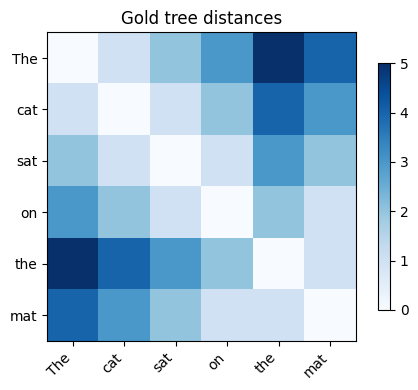

In [3]:
def tree_distances(heads):
    N   = len(heads)
    adj = [[] for _ in range(N)]
    for i, h in enumerate(heads):
        j = h - 1
        if j >= 0:
            adj[i].append(j)
            adj[j].append(i)
    dist = np.full((N, N), np.inf)
    np.fill_diagonal(dist, 0)
    for src in range(N):
        q, seen = deque([(src, 0)]), {src}
        while q:
            node, d = q.popleft()
            dist[src, node] = d
            for nb in adj[node]:
                if nb not in seen:
                    seen.add(nb)
                    q.append((nb, d + 1))
    return dist

gold_dist = tree_distances(heads)

# Print as a labelled table
print('Gold tree distances (d[i,j] = number of edges between word i and word j):')
header = '{:>12}'.format('') + ''.join('{:>8}'.format(w) for w in words)
print(header)
for i, w in enumerate(words):
    row = '{:>12}'.format(w) + ''.join('{:>8}'.format(int(gold_dist[i,j])) for j in range(len(words)))
    print(row)

plt.figure(figsize=(5, 4))
plt.imshow(gold_dist, cmap='Blues')
plt.xticks(range(len(words)), words, rotation=45, ha='right')
plt.yticks(range(len(words)), words)
plt.title('Gold tree distances')
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.show()

---
## Step 3 — Extract gold edges

The gold edges are exactly the direct head-dependent pairs in the tree (one per word, excluding ROOT).
These are the edges we will try to recover via the MST.

In [4]:
gold = {frozenset([i, h-1]) for i, h in enumerate(heads) if h > 0}

print(f'Gold edges ({len(gold)} total, one per word excluding ROOT):')
for e in sorted([sorted(e) for e in gold]):
    i, j = e
    print(f'  {words[i]} -- {words[j]}')

Gold edges (5 total, one per word excluding ROOT):
  The -- cat
  cat -- sat
  sat -- on
  on -- mat
  the -- mat


In [ ]:
import networkx as nx

def draw_parse_graph(words, edge_set, title='', ax=None, highlight=None):
    """
    Draw a dependency tree as an arc diagram.
    words     : list of word strings
    edge_set  : set of frozensets {i, j}  (0-indexed, undirected)
    highlight : set of frozensets to colour green (correct); rest red
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(max(6, len(words) * 1.1), 2.8))

    n = len(words)
    xs = list(range(n))

    # Draw word nodes
    ax.scatter(xs, [0] * n, s=0)
    for i, w in enumerate(words):
        ax.text(i, -0.15, w, ha='center', va='top', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', fc='#dceeff', ec='#5599cc', lw=1))

    # Draw arcs above the words
    for edge in edge_set:
        i, j = sorted(edge)
        mid   = (i + j) / 2
        span  = (j - i) / 2
        color = 'black'
        if highlight is not None:
            color = '#2ecc71' if edge in highlight else '#e74c3c'
        arc = plt.matplotlib.patches.Arc(
            (mid, 0), width=j - i, height=span * 0.9,
            angle=0, theta1=0, theta2=180,
            color=color, lw=1.8
        )
        ax.add_patch(arc)
        # Arrowhead at the right end of the arc
        ax.annotate('', xy=(j, 0), xytext=(j - 0.01, span * 0.45),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    ax.set_xlim(-0.8, n - 0.2)
    ax.set_ylim(-0.5, max(1.2, n * 0.45))
    ax.axis('off')
    ax.set_title(title, fontsize=11, pad=4)


In [ ]:
# Gold parse tree
fig, ax = plt.subplots(figsize=(max(6, len(words) * 1.1), 2.8))
draw_parse_graph(words, gold, title='Gold parse tree', ax=ax)
plt.tight_layout()
plt.show()

---
## Step 4 — Get hidden states from the LM (all layers)

For each word we **average all its subword tokens** across the layer,
then subtract the embedding layer so the probe sees contextual signal only:

$$h^\ell_i = h^\ell_i - h^0_i$$

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True).to(DEVICE).eval()

N_LAYERS   = model.config.num_hidden_layers
HIDDEN_DIM = model.config.hidden_size
print(f'{MODEL_NAME}: {N_LAYERS} transformer layers, hidden_dim={HIDDEN_DIM}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

gpt2: 12 transformer layers, hidden_dim=768


In [6]:
@torch.no_grad()
def get_word_states(words):
    """Returns list of L+1 CPU tensors (n_words, hidden_dim). Index 0 = embedding layer."""
    enc = tokenizer(words, is_split_into_words=True,
                    return_tensors='pt', add_special_tokens=True).to(DEVICE)
    out = model(**enc)
    # Map each token back to its word
    w2t = {}
    for tok_idx, word_idx in enumerate(enc.word_ids()):
        if word_idx is not None:
            w2t.setdefault(word_idx, []).append(tok_idx)
    # Average subword tokens per word, per layer
    layers = []
    for hs in out.hidden_states:       # tuple of (1, seq_len, hidden_dim)
        hs = hs[0].cpu()               # (seq_len, hidden_dim) on CPU
        avg = torch.stack([hs[w2t[i]].mean(0) for i in range(len(words))])
        layers.append(avg)             # (n_words, hidden_dim)
    embed = layers[0]                  # embedding layer (layer 0)
    return [embed] + [l - embed for l in layers[1:]]  # subtract embedding

all_layers = get_word_states(words)    # list of L+1 tensors
print(f'Extracted {len(all_layers)} layers (0=embed + {N_LAYERS} transformer layers)')
print(f'Each tensor shape: {all_layers[1].shape}  (n_words x hidden_dim)')

Extracted 13 layers (0=embed + 12 transformer layers)
Each tensor shape: torch.Size([6, 768])  (n_words x hidden_dim)


---
## Step 5 — B: random vs trained

**B** is a matrix `(hidden_dim, probe_rank)` that projects hidden states into a lower-dimensional space.

| | B | What happens |
|---|---|---|
| **Demo (here)** | `torch.randn * 0.05` — random, never updated | UUAS ~ chance |
| **Training** | starts random, updated by gradient descent on L1 loss | UUAS improves |

Everything else in the pipeline (distances, MST, UUAS) is **identical**.

In [7]:
torch.manual_seed(42)
B = torch.randn(HIDDEN_DIM, PROBE_RANK) * 0.05   # random — not learned
# After training (structural_probe.ipynb), B would be:
#   probe = StructuralProbe(HIDDEN_DIM, PROBE_RANK)
#   ... train with AdamW on L1 distance loss ...
#   B = probe.proj  (same shape, but meaningful values)

print(f'B shape : {B.shape}  (hidden_dim x probe_rank)')
print(f'B range : [{B.min():.4f}, {B.max():.4f}]')

B shape : torch.Size([768, 256])  (hidden_dim x probe_rank)
B range : [-0.2295, 0.2315]


---
## Step 6 — Predict pairwise distances

$$\hat{d}_{ij} = \|B^\top(h_i - h_j)\|^2 = \|Bh_i - Bh_j\|^2$$

Project all word vectors, then compute squared L2 between every pair.

Using layer 6
Predicted distances:
                   The       cat       sat        on       the       mat
         The     0.0006259267.0006229833.0006240184.0006236461.0006297890.000
         cat6259267.000     0.000  3630.125  2928.540  2967.936  3279.539
         sat6229833.000  3630.125     0.000  2802.264  3069.993  3514.852
          on6240184.000  2928.540  2802.264     0.000  2003.976  3259.568
         the6236461.000  2967.936  3069.993  2003.976     0.000  3491.039
         mat6297890.000  3279.539  3514.852  3259.568  3491.039     0.000


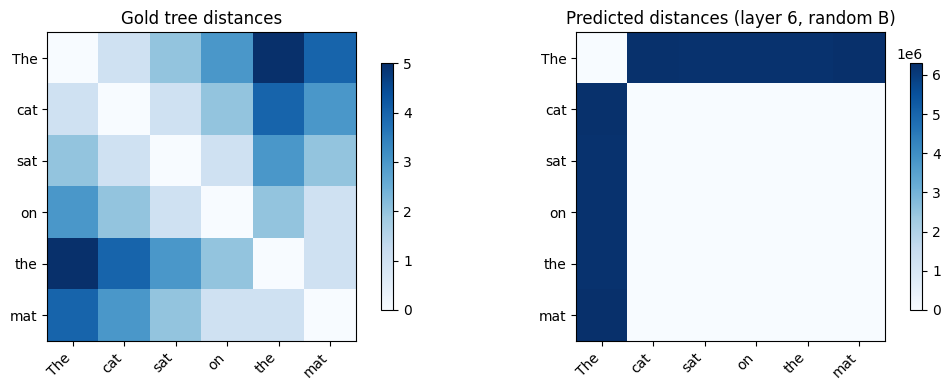

In [19]:
LAYER = 6   # which transformer layer to probe

h = all_layers[LAYER]          # (n_words, hidden_dim) on CPU
z = h @ B                      # (n_words, probe_rank)  — project
diff = z.unsqueeze(1) - z.unsqueeze(0)   # (n, n, rank)
pred_dist = (diff ** 2).sum(-1).numpy()  # (n, n)  predicted distances

print(f'Using layer {LAYER}')
print('Predicted distances:')
header = '{:>12}'.format('') + ''.join('{:>10}'.format(w) for w in words)
print(header)
for i, w in enumerate(words):
    row = '{:>12}'.format(w) + ''.join('{:>10.3f}'.format(pred_dist[i,j]) for j in range(len(words)))
    print(row)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mat, title in zip(axes,
    [gold_dist, pred_dist],
    ['Gold tree distances', f'Predicted distances (layer {LAYER}, random B)']):
    im = ax.imshow(mat, cmap='Blues')
    ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=45, ha='right')
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
## Step 7 — Build Minimum Spanning Tree (MST)

Treat predicted distances as edge weights. The MST gives the most likely tree structure.
A well-trained probe should produce an MST that matches the gold tree.

In [9]:
mst      = minimum_spanning_tree(csr_matrix(pred_dist)).tocoo()
pred_edges = {frozenset([int(i), int(j)]) for i, j in zip(mst.row, mst.col)}

print('Predicted edges (from MST):')
for e in sorted([sorted(e) for e in pred_edges]):
    i, j = e
    correct = frozenset([i, j]) in gold
    print(f'  {words[i]} -- {words[j]}   {"OK" if correct else "WRONG"}')

Predicted edges (from MST):
  The -- sat   WRONG
  cat -- on   WRONG
  sat -- on   OK
  on -- the   WRONG
  on -- mat   OK


In [ ]:
# Gold tree vs Predicted MST — correct edges green, wrong edges red
correct_edges = gold & pred_edges
fig, axes = plt.subplots(1, 2, figsize=(max(12, len(words) * 2.2), 3))
draw_parse_graph(words, gold,       title='Gold parse tree',               ax=axes[0])
draw_parse_graph(words, pred_edges, title=f'Predicted MST (layer {LAYER})',
                 ax=axes[1], highlight=correct_edges)
fig.legend(handles=[
    plt.matplotlib.patches.Patch(color='#2ecc71', label='correct'),
    plt.matplotlib.patches.Patch(color='#e74c3c', label='wrong'),
], loc='lower center', ncol=2, frameon=False)
plt.tight_layout()
plt.show()

---
## Step 8 — Compute UUAS

$$\text{UUAS} = \frac{|\text{pred edges} \cap \text{gold edges}|}{|\text{gold edges}|}$$

In [10]:
correct = len(pred_edges & gold)
total   = len(gold)
score   = correct / total

print(f'Correct edges : {correct} / {total}')
print(f'UUAS          : {score:.3f}   (random B, layer {LAYER})')
print()
print('After training B, UUAS should rise to ~0.7-0.8 on the best layer.')

Correct edges : 2 / 5
UUAS          : 0.400   (random B, layer 6)

After training B, UUAS should rise to ~0.7-0.8 on the best layer.


---
## Step 9 — Sweep all layers

Repeat steps 6-8 for every layer. This shows which layer encodes syntax best.

In [11]:
layer_scores = []
for layer_idx in range(1, N_LAYERS + 1):
    h     = all_layers[layer_idx]
    z     = h @ B
    diff  = z.unsqueeze(1) - z.unsqueeze(0)
    pdist = (diff ** 2).sum(-1).numpy()
    mst   = minimum_spanning_tree(csr_matrix(pdist)).tocoo()
    pedges = {frozenset([int(i), int(j)]) for i, j in zip(mst.row, mst.col)}
    layer_scores.append(len(pedges & gold) / len(gold))
    print(f'  Layer {layer_idx:2d}  UUAS = {layer_scores[-1]:.3f}')

best = int(np.argmax(layer_scores)) + 1
print(f'\nBest layer: {best}  ({max(layer_scores):.3f})')

  Layer  1  UUAS = 0.000
  Layer  2  UUAS = 0.000
  Layer  3  UUAS = 0.000
  Layer  4  UUAS = 0.000
  Layer  5  UUAS = 0.000
  Layer  6  UUAS = 0.400
  Layer  7  UUAS = 0.200
  Layer  8  UUAS = 0.200
  Layer  9  UUAS = 0.200
  Layer 10  UUAS = 0.200
  Layer 11  UUAS = 0.200
  Layer 12  UUAS = 0.200

Best layer: 6  (0.400)


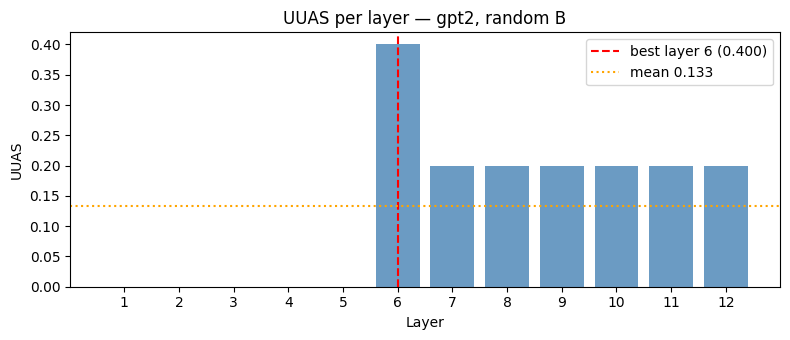

In [12]:
layers = list(range(1, N_LAYERS + 1))
plt.figure(figsize=(8, 3.5))
plt.bar(layers, layer_scores, color='steelblue', alpha=0.8)
plt.axvline(best, color='red', linestyle='--', label=f'best layer {best} ({max(layer_scores):.3f})')
plt.axhline(np.mean(layer_scores), color='orange', linestyle=':', label=f'mean {np.mean(layer_scores):.3f}')
plt.xlabel('Layer'); plt.ylabel('UUAS')
plt.title(f'UUAS per layer — {MODEL_NAME}, random B')
plt.xticks(layers); plt.legend(); plt.tight_layout(); plt.show()